# Colab 06 — Random Forest với threshold tối ưu F-beta (beta=1.75)

Notebook giữ nguyên dữ liệu, feature, model và chronological split của `colab_01..05`. Chỉ thay **policy chọn threshold**: tối đa hóa F-beta trên validation với `beta=1.75`, rồi refit trên train+validation và đánh giá OOT test một lần. Test không tham gia chọn threshold.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, average_precision_score, brier_score_loss,
                             confusion_matrix, f1_score, fbeta_score,
                             precision_recall_curve, precision_score, recall_score,
                             roc_auc_score)

BETA = 1.75
TRAIN_MAX_STEP = 520
VAL_MAX_STEP = 631
SEED = 20_260_727

cwd = Path.cwd()
candidates = [cwd / '_cache', cwd / 'notebooks' / 'colab' / '_cache']
CACHE_DIR = next((p for p in candidates if (p / 'modeling_frame.parquet').exists()), None)
if CACHE_DIR is None:
    raise FileNotFoundError('Chạy colab_02..04 trước để tạo _cache/modeling_frame.parquet và tuning.json')
print('CACHE_DIR =', CACHE_DIR.resolve())

CACHE_DIR = C:\workspace\pit-fintech\notebooks\colab\_cache


## Nạp đúng frame, features và RF params của run trước

In [2]:
frame = pd.read_parquet(CACHE_DIR / 'modeling_frame.parquet')
tuning = json.loads((CACHE_DIR / 'tuning.json').read_text(encoding='utf-8'))
FEATURES = tuning['features']
BEST_PARAMS = tuning['best_params']

required = set(FEATURES) | {'step', 'isFraud'}
missing = sorted(required - set(frame.columns))
if missing:
    raise ValueError(f'Modeling frame thiếu cột: {missing}')

train = frame[frame['step'] <= TRAIN_MAX_STEP].copy()
val = frame[(frame['step'] > TRAIN_MAX_STEP) & (frame['step'] <= VAL_MAX_STEP)].copy()
test = frame[frame['step'] > VAL_MAX_STEP].copy()
for name, part in [('train', train), ('val', val), ('test', test)]:
    print(f'{name:5s}: step={part.step.min()}..{part.step.max()} rows={len(part):,} frauds={int(part.isFraud.sum()):,} rate={part.isFraud.mean():.5%}')
print('FEATURES:', FEATURES)
print('BEST_PARAMS:', BEST_PARAMS)

train: step=1..520 rows=2,653,729 frauds=5,781 rate=0.21784%
val  : step=521..631 rows=78,701 frauds=1,180 rate=1.49935%
test : step=632..743 rows=37,979 frauds=1,252 rate=3.29656%
FEATURES: ['current_amount', 'transaction_type_transfer', 'pit_prior_count_1h', 'pit_prior_amount_1h', 'pit_prior_count_24h', 'pit_prior_amount_24h', 'pit_prior_amount_168h', 'pit_distinct_senders_24h', 'pit_distinct_senders_168h', 'pit_steps_since_last_event']
BEST_PARAMS: {'max_depth': 12, 'min_samples_leaf': 35, 'max_features': 'log2', 'n_estimators': 25}


In [3]:
def make_rf(params=None):
    base = dict(
        n_estimators=25, max_depth=16, min_samples_leaf=20,
        min_samples_split=2, max_features='sqrt', max_samples=0.3,
        class_weight='balanced_subsample', n_jobs=-1, random_state=SEED,
    )
    base.update(params or {})
    return RandomForestClassifier(**base)

selection_model = make_rf(BEST_PARAMS)
selection_model.fit(train[FEATURES], train['isFraud'])
pval = selection_model.predict_proba(val[FEATURES])[:, 1]
yval = val['isFraud'].to_numpy()

## Chọn threshold trên validation bằng F-beta

Với beta=1.75, recall có trọng số lớn hơn precision. PR-AUC/ROC-AUC không đổi khi đổi threshold; F-beta, precision, recall và confusion matrix sẽ đổi.

,beta,threshold,precision,recall,f1,f_beta_1_75,pr_auc,roc_auc
0,1.75,0.605939,0.080129,0.715254,0.144113,0.24237,0.226613,0.83357


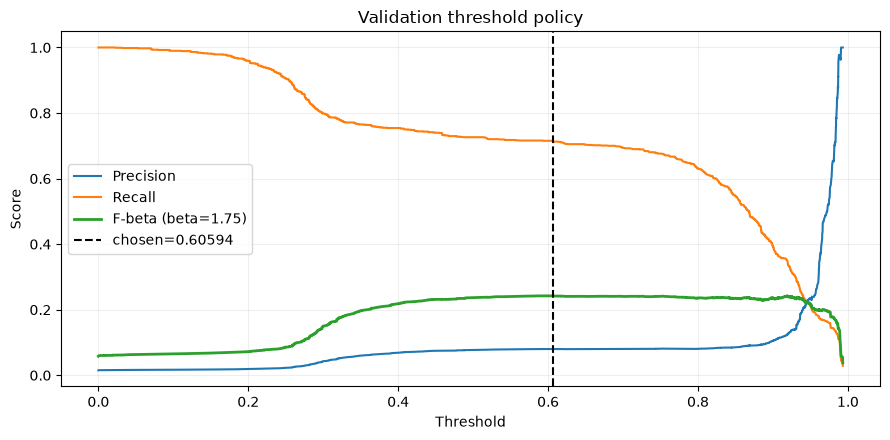

In [4]:
prec_curve, rec_curve, thresholds = precision_recall_curve(yval, pval)
beta2 = BETA ** 2
fbeta_curve = (1 + beta2) * prec_curve[:-1] * rec_curve[:-1] / (beta2 * prec_curve[:-1] + rec_curve[:-1] + 1e-12)
best_idx = int(np.nanargmax(fbeta_curve))
CHOSEN_THRESHOLD = float(thresholds[best_idx])
val_pred = (pval >= CHOSEN_THRESHOLD).astype(int)

val_report = {
    'beta': BETA, 'threshold': CHOSEN_THRESHOLD,
    'precision': precision_score(yval, val_pred, zero_division=0),
    'recall': recall_score(yval, val_pred, zero_division=0),
    'f1': f1_score(yval, val_pred, zero_division=0),
    'f_beta_1_75': fbeta_score(yval, val_pred, beta=BETA, zero_division=0),
    'pr_auc': average_precision_score(yval, pval),
    'roc_auc': roc_auc_score(yval, pval),
}
display(pd.DataFrame([val_report]))

plt.figure(figsize=(9, 4.5))
plt.plot(thresholds, prec_curve[:-1], label='Precision')
plt.plot(thresholds, rec_curve[:-1], label='Recall')
plt.plot(thresholds, fbeta_curve, label='F-beta (beta=1.75)', linewidth=2)
plt.axvline(CHOSEN_THRESHOLD, color='black', linestyle='--', label=f'chosen={CHOSEN_THRESHOLD:.5f}')
plt.xlabel('Threshold'); plt.ylabel('Score'); plt.title('Validation threshold policy')
plt.legend(); plt.grid(alpha=0.2); plt.tight_layout(); plt.show()

## Refit train+validation và đánh giá OOT test một lần

In [5]:
train_val = frame[frame['step'] <= VAL_MAX_STEP]
final_model = make_rf(BEST_PARAMS)
final_model.fit(train_val[FEATURES], train_val['isFraud'])

ytest = test['isFraud'].to_numpy()
ptest = final_model.predict_proba(test[FEATURES])[:, 1]
test_pred = (ptest >= CHOSEN_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(ytest, test_pred, labels=[0, 1]).ravel()
test_report = {
    'test_rows': len(test), 'test_frauds': int(ytest.sum()),
    'prevalence': float(ytest.mean()), 'beta': BETA,
    'threshold_selected_on_validation': CHOSEN_THRESHOLD,
    'pr_auc': average_precision_score(ytest, ptest),
    'roc_auc': roc_auc_score(ytest, ptest),
    'brier': brier_score_loss(ytest, ptest),
    'precision': precision_score(ytest, test_pred, zero_division=0),
    'recall': recall_score(ytest, test_pred, zero_division=0),
    'f1': f1_score(ytest, test_pred, zero_division=0),
    'f_beta_1_75': fbeta_score(ytest, test_pred, beta=BETA, zero_division=0),
    'accuracy': accuracy_score(ytest, test_pred),
    'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp),
}
display(pd.DataFrame([test_report]).T.rename(columns={0: 'value'}))

,value
test_rows,37979.000000
test_frauds,1252.000000
prevalence,0.032966
beta,1.750000
threshold_selected_on_validation,0.605939
pr_auc,0.317233
roc_auc,0.808628
brier,0.212620
precision,0.120333
recall,0.715655


In [6]:
artifact = {
    'selection_split': {'train': [1, 520], 'validation': [521, 631], 'test': [632, 743]},
    'threshold_policy': 'maximize_validation_fbeta',
    'validation': val_report, 'test': test_report,
    'features': FEATURES, 'best_params': BEST_PARAMS,
}
out = CACHE_DIR / 'random_forest_fbeta_175_report.json'
out.write_text(json.dumps(artifact, indent=2), encoding='utf-8')
print('Đã lưu:', out.resolve())

Đã lưu: C:\workspace\pit-fintech\notebooks\colab\_cache\random_forest_fbeta_175_report.json


## Log và đăng ký model lên MLflow

Cell này lưu estimator đã refit, threshold F-beta, metric validation/OOT, signature và input example. Guard theo policy/beta/threshold giúp chạy lại cell mà không tạo version trùng.

In [7]:
# Nếu cần server khác: đặt biến môi trường MLFLOW_TRACKING_URI trước khi chạy cell.
import os
import mlflow
import mlflow.sklearn
from mlflow import MlflowClient
from mlflow.models import infer_signature

MLFLOW_TRACKING_URI = os.environ.get('MLFLOW_TRACKING_URI', 'http://100.116.36.6:5000')
MLFLOW_EXPERIMENT = 'paysim-fraud-rf-colab'
REGISTERED_MODEL_NAME = 'paysim-fraud-rf'
expected_threshold = str(float(CHOSEN_THRESHOLD))

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)
client = MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)
existing = None
for mv in client.search_model_versions(f"name='{REGISTERED_MODEL_NAME}'"):
    tags = mv.tags or {}
    if (tags.get('threshold_policy') == 'maximize_validation_fbeta'
            and tags.get('beta') == str(BETA)
            and tags.get('decision_threshold') == expected_threshold):
        existing = mv
        break

if existing is not None:
    print(f'Đã tồn tại: {REGISTERED_MODEL_NAME} version {existing.version}, run {existing.run_id}')
else:
    input_example = test[FEATURES].head(5).copy()
    signature = infer_signature(input_example, final_model.predict_proba(input_example))
    with mlflow.start_run(run_name='rf__fbeta_1_75_oot') as run:
        mlflow.set_tags({
            'stage': 'fbeta_1_75_oot', 'model_family': 'random_forest',
            'threshold_policy': 'maximize_validation_fbeta',
            'threshold_selected_on': 'validation_only', 'beta': str(BETA),
            'sealed_test_touched': 'true',
        })
        mlflow.log_params({
            **BEST_PARAMS, 'threshold': CHOSEN_THRESHOLD, 'beta': BETA,
            'train_steps': '1-520', 'validation_steps': '521-631',
            'test_steps': '632-743', 'n_features': len(FEATURES),
        })
        mlflow.log_metrics({
            **{f'validation_{k}': float(v) for k, v in val_report.items()
               if k not in {'beta', 'threshold'}},
            **{f'test_{k.lower()}': float(v) for k, v in test_report.items()
               if k not in {'beta', 'threshold_selected_on_validation'}},
        })
        mlflow.log_artifact(str(out), artifact_path='evaluation')
        mlflow.sklearn.log_model(
            final_model, name='model', registered_model_name=REGISTERED_MODEL_NAME,
            signature=signature, input_example=input_example,
        )
        run_id = run.info.run_id
    versions = client.search_model_versions(
        f"name='{REGISTERED_MODEL_NAME}' and run_id='{run_id}'"
    )
    if len(versions) != 1:
        raise RuntimeError(f'Không xác định duy nhất model version cho run {run_id}')
    version = versions[0].version
    for key, value in {
        'decision_threshold': CHOSEN_THRESHOLD,
        'threshold_policy': 'maximize_validation_fbeta',
        'beta': BETA, 'test_recall': test_report['recall'],
        'test_fbeta_1_75': test_report['f_beta_1_75'],
    }.items():
        client.set_model_version_tag(REGISTERED_MODEL_NAME, version, key, str(value))
    print(f'Đã đăng ký: {REGISTERED_MODEL_NAME} version {version}, run {run_id}')

C:\workspace\pit-fintech\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Đã tồn tại: paysim-fraud-rf version 3, run 4192dfca0a9740d6994f732890995ae8
